# Building a Cancer Clinical Data Warehouse with TCGA, SQL, and Python

This notebook builds a complete miniature clinical data warehouse from real TCGA data in the
[Genomic Data Commons API](https://api.gdc.cancer.gov).

We will:

1. Install any missing Python libraries.
2. Download TCGA case, diagnosis, treatment, exposure, follow-up, and mutation-file metadata programmatically.
3. Convert nested GDC JSON into clean relational tables.
4. Store the tables in a local SQLite database named `tcga_warehouse.db`.
5. Run SQL queries that answer useful cancer-data questions.
6. Turn query results into plots, including a Kaplan-Meier survival curve.

The notebook is written for someone who is new to SQL. Each query is explained in plain English before it is run.

**Important scientific note:** TCGA is a research dataset. The analyses here are educational examples, not clinical guidance.


# 📦 Data Source & Project Overview

***

## 🏛️ Where Does the Data Come From?

The data used in this project comes from a real, publicly available cancer research database maintained by the **U.S. National Cancer Institute (NCI)**. Below is the full trail — from the original research program down to the exact link used in this script.

***

## 🗺️ Data Trail — From Source to Script

```
🏥 The Cancer Genome Atlas (TCGA)
   └── A U.S. government-funded program that collected clinical data,
       tumour samples, and genomic information from over 11,000 real
       cancer patients across 33 cancer types.
   
       🌐 Official page: https://www.cancer.gov/ccg/research/genome-sequencing/tcga

           ↓

🗄️ NCI Genomic Data Commons (GDC)
   └── The government database that stores and publicly shares all TCGA data.
       You can browse it visually like a website, or access it with code.
   
       🌐 Data portal (visual): https://portal.gdc.cancer.gov
       📖 API documentation:   https://docs.gdc.cancer.gov/API/Users_Guide/Getting_Started/

           ↓

🔌 GDC REST API
   └── A programmatic access point that lets Python download data automatically,
       without clicking through the website.
   
       🔗 Base address used in this script:
       API = "https://api.gdc.cancer.gov"

           ↓

📥 This Script
   └── Sends requests to:  https://api.gdc.cancer.gov/cases
       Filters data to the following 5 TCGA cancer projects:
       
       ┌─────────────┬──────────────────────────────────────┐
       │ Project ID  │ Cancer Type                          │
       ├─────────────┼──────────────────────────────────────┤
       │ TCGA-BRCA   │ Breast Invasive Carcinoma            │
       │ TCGA-LUAD   │ Lung Adenocarcinoma                  │
       │ TCGA-COAD   │ Colon Adenocarcinoma                 │
       │ TCGA-GBM    │ Glioblastoma Multiforme (Brain)      │
       │ TCGA-PRAD   │ Prostate Adenocarcinoma              │
       └─────────────┴──────────────────────────────────────┘
       
       Downloads up to 500 patient cases per cancer type.
```

***

## 📋 What Data Is Downloaded?

For each patient case, the script retrieves the following clinical information:

| Category | Fields Retrieved |
|---|---|
| **Patient** | ID, gender, race, ethnicity, age, vital status |
| **Diagnosis** | Age at diagnosis, tumour stage, primary diagnosis, days to death, days to last follow-up |
| **Treatment** | Treatment type, therapy name, days to treatment start |
| **Exposure** | Smoking status, pack years smoked, alcohol history, BMI |
| **Mutation** | Variant count from open MAF files (somatic mutation proxy) |

***

## 🔓 Is This Data Free to Use?

Yes. TCGA data is **publicly available and free to use** for research and educational purposes under the [GDC Data Access Policy](https://gdc.cancer.gov/access-data/data-access-policies). The clinical metadata used in this project is open-access — no account or special permission is needed.

***

## ⚠️ Scientific Disclaimer

All analyses in this notebook are **educational examples** and are not intended as clinical guidance. Mutation burden values computed here are a simplified teaching proxy — they are not equivalent to a formally normalised Tumour Mutational Burden (TMB) value used in clinical settings.

***

## 📎 Quick Reference Links

| Resource | Link |
|---|---|
| TCGA Program Overview | https://www.cancer.gov/ccg/research/genome-sequencing/tcga |
| GDC Data Portal (visual browser) | https://portal.gdc.cancer.gov |
| GDC API Documentation | https://docs.gdc.cancer.gov/API/Users_Guide/Getting_Started/ |
| GDC API Base URL (used in script) | https://api.gdc.cancer.gov |
| GDC Data Access Policy | https://gdc.cancer.gov/access-data/data-access-policies |

## 1. Install and Import Libraries

A Jupyter notebook often runs on a machine that may not have every package installed yet.
The cell below checks for the packages we need and installs only the missing ones.

We use:

- `requests` to call the GDC REST API.
- `pandas` and `numpy` for tabular data.
- `sqlite3`, which is built into Python, for the local SQL database.
- `matplotlib` and `seaborn` for plots.
- `lifelines` for the Kaplan-Meier survival curve.


In [1]:
import importlib
import subprocess
import sys

required_packages = {
    "requests": "requests",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib.pyplot": "matplotlib",
    "seaborn": "seaborn",
    "lifelines": "lifelines",
    "kiwisolver": "kiwisolver",
    "PIL": "pillow",
}

missing_or_broken = []
for import_name, package_name in required_packages.items():
    try:
        importlib.import_module(import_name)
    except Exception as exc:
        print(f"{package_name} needs installation or repair: {exc}")
        missing_or_broken.append(package_name)
        root_name = import_name.split(".")[0]
        for loaded_name in list(sys.modules):
            if loaded_name == root_name or loaded_name.startswith(root_name + "."):
                del sys.modules[loaded_name]

if missing_or_broken:
    print("Installing/upgrading packages:", missing_or_broken)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall", *missing_or_broken]
    )
    importlib.invalidate_caches()
    for import_name in required_packages:
        root_name = import_name.split(".")[0]
        for loaded_name in list(sys.modules):
            if loaded_name == root_name or loaded_name.startswith(root_name + "."):
                del sys.modules[loaded_name]
else:
    print("All required packages are already installed.")


All required packages are already installed.


In [2]:
import gzip
import io
import json
import math
import sqlite3
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display
from lifelines import KaplanMeierFitter

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

GDC_API = "https://api.gdc.cancer.gov"
DB_PATH = Path("tcga_warehouse.db")
CACHE_DIR = Path("tcga_api_cache")
CACHE_DIR.mkdir(exist_ok=True)

PROJECT_IDS = ["TCGA-BRCA", "TCGA-LUAD", "TCGA-COAD", "TCGA-GBM", "TCGA-PRAD"]
MAX_CASES_PER_PROJECT = 500

# Mutation data are downloaded from open masked somatic mutation MAF files.
# This is intentionally capped so the notebook stays practical to run in a classroom.
MAX_MUTATION_CASES_PER_PROJECT = 50

print("Projects:", ", ".join(PROJECT_IDS))
print("Clinical case cap per project:", MAX_CASES_PER_PROJECT)
print("Mutation-file cap per project:", MAX_MUTATION_CASES_PER_PROJECT)


Projects: TCGA-BRCA, TCGA-LUAD, TCGA-COAD, TCGA-GBM, TCGA-PRAD
Clinical case cap per project: 500
Mutation-file cap per project: 50


## 2. Download Clinical Data from the GDC API

TCGA data in the GDC API comes back as nested JSON. A single case can contain:

- one demographic record,
- one or more diagnoses,
- one or more treatments,
- one or more exposure records,
- zero or more follow-up records.

SQL databases prefer rectangular tables. We will download the nested JSON first, then flatten it into SQL-ready tables.

The API request uses pagination. Pagination means we do not ask the server for everything in one giant response.
Instead, we ask for page 1, then page 2, then page 3, until we reach the project limit.


In [3]:
CLINICAL_FIELDS = [
    "case_id",
    "submitter_id",
    "project.project_id",
    "project.name",
    "project.primary_site",
    "demographic.gender",
    "demographic.race",
    "demographic.ethnicity",
    "demographic.age_at_index",
    "demographic.vital_status",
    "diagnoses.age_at_diagnosis",
    "diagnoses.primary_diagnosis",
    "diagnoses.tumor_stage",
    "diagnoses.days_to_last_follow_up",
    "diagnoses.days_to_death",
    "diagnoses.morphology",
    "diagnoses.tissue_or_organ_of_origin",
    "diagnoses.prior_malignancy",
    "treatments.treatment_type",
    "treatments.treatment_or_therapy",
    "treatments.days_to_treatment_start",
    "exposures.alcohol_history",
    "exposures.tobacco_smoking_status",
    "exposures.pack_years_smoked",
    "exposures.bmi",
    "follow_ups.days_to_follow_up",
    "follow_ups.progression_or_recurrence",
    "follow_ups.disease_response",
]

EXPAND_FIELDS = "project,demographic,diagnoses,treatments,exposures,follow_ups"


def cache_path(name):
    safe_name = name.replace("/", "_").replace(":", "_").replace("?", "_")
    return CACHE_DIR / safe_name


def request_with_retries(url, params=None, timeout=60, max_tries=4):
    """Small retry helper for public API calls."""
    last_error = None
    for attempt in range(1, max_tries + 1):
        try:
            response = requests.get(url, params=params, timeout=timeout)
            if response.status_code in {429, 500, 502, 503, 504}:
                raise requests.HTTPError(
                    f"Temporary HTTP {response.status_code}",
                    response=response,
                )
            response.raise_for_status()
            return response
        except Exception as exc:
            last_error = exc
            wait = min(2 ** attempt, 20)
            print(f"Request attempt {attempt}/{max_tries} failed; retrying in {wait}s. Reason: {exc}")
            time.sleep(wait)
    raise RuntimeError(f"Request failed after {max_tries} tries: {last_error}")


def gdc_get_json(endpoint, params, cache_name=None):
    """Download JSON from GDC, with a local cache so re-running the notebook is faster."""
    if cache_name:
        path = cache_path(cache_name)
        if path.exists():
            with path.open("r", encoding="utf-8") as f:
                return json.load(f)

    response = request_with_retries(f"{GDC_API}/{endpoint.lstrip('/')}", params=params)
    payload = response.json()

    if cache_name:
        with cache_path(cache_name).open("w", encoding="utf-8") as f:
            json.dump(payload, f)

    return payload


def project_filter(project_id):
    return {
        "op": "=",
        "content": {
            "field": "project.project_id",
            "value": project_id,
        },
    }


def download_cases_for_project(project_id, max_cases=500, page_size=100):
    hits = []
    offset = 0

    while len(hits) < max_cases:
        size = min(page_size, max_cases - len(hits))
        params = {
            "filters": json.dumps(project_filter(project_id)),
            "fields": ",".join(CLINICAL_FIELDS),
            "expand": EXPAND_FIELDS,
            "format": "JSON",
            "size": size,
            "from": offset,
            "sort": "submitter_id:asc",
        }
        payload = gdc_get_json(
            "cases",
            params,
            cache_name=f"cases_{project_id}_{offset}_{size}.json",
        )
        page_hits = payload.get("data", {}).get("hits", [])
        hits.extend(page_hits)

        pagination = payload.get("data", {}).get("pagination", {})
        total_available = pagination.get("total", 0)
        print(f"{project_id}: downloaded {len(hits)} of up to {min(max_cases, total_available)} cases")

        if not page_hits or len(hits) >= total_available:
            break

        offset += size
        time.sleep(0.1)

    return hits[:max_cases]


In [4]:
raw_cases = []
for project_id in PROJECT_IDS:
    raw_cases.extend(download_cases_for_project(project_id, MAX_CASES_PER_PROJECT))

print(f"\nTotal downloaded cases: {len(raw_cases):,}")

project_case_counts = pd.Series(
    [case.get("project", {}).get("project_id") for case in raw_cases],
    name="project_id",
).value_counts().rename_axis("project_id").reset_index(name="downloaded_cases")

display(project_case_counts)


TCGA-BRCA: downloaded 100 of up to 500 cases
TCGA-BRCA: downloaded 200 of up to 500 cases
TCGA-BRCA: downloaded 300 of up to 500 cases
TCGA-BRCA: downloaded 400 of up to 500 cases
TCGA-BRCA: downloaded 500 of up to 500 cases
TCGA-LUAD: downloaded 100 of up to 500 cases
TCGA-LUAD: downloaded 200 of up to 500 cases
TCGA-LUAD: downloaded 300 of up to 500 cases
TCGA-LUAD: downloaded 400 of up to 500 cases
TCGA-LUAD: downloaded 500 of up to 500 cases
TCGA-COAD: downloaded 100 of up to 461 cases
TCGA-COAD: downloaded 200 of up to 461 cases
TCGA-COAD: downloaded 300 of up to 461 cases
TCGA-COAD: downloaded 400 of up to 461 cases
TCGA-COAD: downloaded 461 of up to 461 cases
TCGA-GBM: downloaded 100 of up to 500 cases
TCGA-GBM: downloaded 200 of up to 500 cases
TCGA-GBM: downloaded 300 of up to 500 cases
TCGA-GBM: downloaded 400 of up to 500 cases
TCGA-GBM: downloaded 500 of up to 500 cases
TCGA-PRAD: downloaded 100 of up to 500 cases
TCGA-PRAD: downloaded 200 of up to 500 cases
TCGA-PRAD: down

,project_id,downloaded_cases
0,TCGA-BRCA,500
1,TCGA-LUAD,500
2,TCGA-GBM,500
3,TCGA-PRAD,500
4,TCGA-COAD,461


## 3. Convert Nested JSON into Relational Tables

A relational database stores information in tables.

The required warehouse has five clinical tables:

1. `patients`: one row per patient/case.
2. `diagnoses`: one row per diagnosis.
3. `treatments`: one row per treatment.
4. `exposures`: one row per exposure record.
5. `cancer_projects`: one row per TCGA project.

The key idea is `case_id`.

`case_id` is the patient-level identifier from GDC. It appears in every clinical table, so SQL can connect the tables later.
In database language, `patients.case_id` is the **primary key** of the patient table, and the `case_id` columns in the other
tables are **foreign keys** back to `patients`.

We also create one compact analysis table called `mutation_burden`. Mutation counts are not part of the clinical case JSON,
so we compute them from open masked somatic mutation MAF files and store the result as one row per patient with a downloaded MAF file.


In [5]:
def as_records(value):
    """Return a list if the API value is a list; otherwise return an empty list."""
    return value if isinstance(value, list) else []


def clean_value(value):
    """Convert nested leftovers and NaN-like values into database-friendly values."""
    if isinstance(value, (dict, list)):
        return json.dumps(value)
    if value in {"", "None", "null"}:
        return None
    return value


def get_nested(record, *keys):
    current = record
    for key in keys:
        if not isinstance(current, dict):
            return None
        current = current.get(key)
    return clean_value(current)


def make_df(rows, columns):
    df = pd.DataFrame(rows)
    for column in columns:
        if column not in df.columns:
            df[column] = None
    df = df[columns]
    return df.replace({np.nan: None})


PATIENT_COLUMNS = [
    "case_id",
    "submitter_id",
    "project_id",
    "gender",
    "race",
    "ethnicity",
    "age_at_index",
    "vital_status",
]

DIAGNOSIS_COLUMNS = [
    "case_id",
    "age_at_diagnosis",
    "primary_diagnosis",
    "tumor_stage",
    "days_to_last_follow_up",
    "days_to_death",
    "morphology",
    "tissue_or_organ",
    "prior_malignancy",
]

TREATMENT_COLUMNS = [
    "case_id",
    "treatment_type",
    "treatment_or_therapy",
    "days_to_treatment_start",
]

EXPOSURE_COLUMNS = [
    "case_id",
    "alcohol_history",
    "tobacco_smoking_status",
    "pack_years_smoked",
    "bmi",
]

PROJECT_COLUMNS = ["project_id", "cancer_type_name", "primary_site"]

patient_rows = []
diagnosis_rows = []
treatment_rows = []
exposure_rows = []
project_rows_by_id = {}

for case in raw_cases:
    case_id = case.get("case_id") or case.get("id")
    project = case.get("project") or {}
    demographic = case.get("demographic") or {}
    project_id = project.get("project_id")

    patient_rows.append(
        {
            "case_id": case_id,
            "submitter_id": clean_value(case.get("submitter_id")),
            "project_id": clean_value(project_id),
            "gender": clean_value(demographic.get("gender")),
            "race": clean_value(demographic.get("race")),
            "ethnicity": clean_value(demographic.get("ethnicity")),
            "age_at_index": clean_value(demographic.get("age_at_index")),
            "vital_status": clean_value(demographic.get("vital_status")),
        }
    )

    if project_id and project_id not in project_rows_by_id:
        primary_site = project.get("primary_site")
        if isinstance(primary_site, list):
            primary_site = ", ".join(primary_site)
        project_rows_by_id[project_id] = {
            "project_id": project_id,
            "cancer_type_name": clean_value(project.get("name")),
            "primary_site": clean_value(primary_site),
        }

    for diagnosis in as_records(case.get("diagnoses")):
        diagnosis_rows.append(
            {
                "case_id": case_id,
                "age_at_diagnosis": clean_value(diagnosis.get("age_at_diagnosis")),
                "primary_diagnosis": clean_value(diagnosis.get("primary_diagnosis")),
                "tumor_stage": clean_value(diagnosis.get("tumor_stage")),
                "days_to_last_follow_up": clean_value(diagnosis.get("days_to_last_follow_up")),
                "days_to_death": clean_value(diagnosis.get("days_to_death")),
                "morphology": clean_value(diagnosis.get("morphology")),
                "tissue_or_organ": clean_value(diagnosis.get("tissue_or_organ_of_origin")),
                "prior_malignancy": clean_value(diagnosis.get("prior_malignancy")),
            }
        )

    for treatment in as_records(case.get("treatments")):
        treatment_rows.append(
            {
                "case_id": case_id,
                "treatment_type": clean_value(treatment.get("treatment_type")),
                "treatment_or_therapy": clean_value(treatment.get("treatment_or_therapy")),
                "days_to_treatment_start": clean_value(treatment.get("days_to_treatment_start")),
            }
        )

    for exposure in as_records(case.get("exposures")):
        exposure_rows.append(
            {
                "case_id": case_id,
                "alcohol_history": clean_value(exposure.get("alcohol_history")),
                "tobacco_smoking_status": clean_value(exposure.get("tobacco_smoking_status")),
                "pack_years_smoked": clean_value(exposure.get("pack_years_smoked")),
                "bmi": clean_value(exposure.get("bmi")),
            }
        )

patients_df = make_df(patient_rows, PATIENT_COLUMNS).drop_duplicates("case_id")
diagnoses_df = make_df(diagnosis_rows, DIAGNOSIS_COLUMNS)
treatments_df = make_df(treatment_rows, TREATMENT_COLUMNS)
exposures_df = make_df(exposure_rows, EXPOSURE_COLUMNS)
cancer_projects_df = make_df(list(project_rows_by_id.values()), PROJECT_COLUMNS).sort_values("project_id")

table_preview_counts = pd.DataFrame(
    {
        "table": ["patients", "diagnoses", "treatments", "exposures", "cancer_projects"],
        "rows": [
            len(patients_df),
            len(diagnoses_df),
            len(treatments_df),
            len(exposures_df),
            len(cancer_projects_df),
        ],
    }
)

display(table_preview_counts)
display(patients_df.head())


,table,rows
0,patients,2461
1,diagnoses,3531
2,treatments,0
3,exposures,442
4,cancer_projects,5


,case_id,submitter_id,project_id,gender,race,ethnicity,age_at_index,vital_status
0,6e7d5ec6-a469-467c-b748-237353c23416,TCGA-3C-AAAU,TCGA-BRCA,female,white,not hispanic or latino,55.0,Alive
1,55262fcb-1b01-4480-b322-36570430c917,TCGA-3C-AALI,TCGA-BRCA,female,black or african american,not hispanic or latino,50.0,Alive
2,427d0648-3f77-4ffc-b52c-89855426d647,TCGA-3C-AALJ,TCGA-BRCA,female,black or african american,not hispanic or latino,62.0,Alive
3,c31900a4-5dcd-4022-97ac-638e86e889e4,TCGA-3C-AALK,TCGA-BRCA,female,black or african american,not hispanic or latino,52.0,Alive
4,6623fc5e-00be-4476-967a-cbd55f676ea6,TCGA-4H-AAAK,TCGA-BRCA,female,white,not hispanic or latino,50.0,Alive


## 4. Add a Mutation Burden Proxy from Open MAF Files

Clinical metadata does not contain a ready-made mutation count.

To analyze mutation burden, we query GDC's open **Masked Somatic Mutation** files. Each MAF file is a tab-separated text file
where each data row is a somatic variant. For each selected patient, we download one MAF file and count the number of variant rows.

This is a practical teaching-friendly **mutation burden proxy**:

- It is real mutation data from GDC.
- It is simple enough to compute in a notebook.
- It is not the same as a formal clinical tumor mutational burden value, because formal TMB is usually normalized by assay size.


In [6]:
def mutation_file_filter(project_id):
    return {
        "op": "and",
        "content": [
            {
                "op": "=",
                "content": {
                    "field": "cases.project.project_id",
                    "value": project_id,
                },
            },
            {
                "op": "=",
                "content": {
                    "field": "data_category",
                    "value": "Simple Nucleotide Variation",
                },
            },
            {
                "op": "=",
                "content": {
                    "field": "data_type",
                    "value": "Masked Somatic Mutation",
                },
            },
            {
                "op": "=",
                "content": {
                    "field": "access",
                    "value": "open",
                },
            },
        ],
    }


def download_mutation_file_metadata(project_id):
    fields = [
        "file_id",
        "file_name",
        "file_size",
        "data_type",
        "data_format",
        "experimental_strategy",
        "cases.case_id",
        "cases.submitter_id",
    ]
    hits = []
    offset = 0
    page_size = 1000

    while True:
        params = {
            "filters": json.dumps(mutation_file_filter(project_id)),
            "fields": ",".join(fields),
            "expand": "cases",
            "format": "JSON",
            "size": page_size,
            "from": offset,
            "sort": "file_size:asc",
        }
        payload = gdc_get_json(
            "files",
            params,
            cache_name=f"mutation_files_{project_id}_{offset}_{page_size}.json",
        )
        page_hits = payload.get("data", {}).get("hits", [])
        hits.extend(page_hits)

        pagination = payload.get("data", {}).get("pagination", {})
        total = pagination.get("total", 0)
        if not page_hits or len(hits) >= total:
            break
        offset += page_size
        time.sleep(0.1)

    return hits


def count_maf_variants(file_id):
    count_cache = cache_path(f"maf_count_{file_id}.json")
    if count_cache.exists():
        with count_cache.open("r", encoding="utf-8") as f:
            return json.load(f)["mutation_count"]

    response = request_with_retries(f"{GDC_API}/data/{file_id}", timeout=120)
    raw = response.content

    if raw[:2] == b"\x1f\x8b":
        stream = gzip.GzipFile(fileobj=io.BytesIO(raw))
        text_stream = io.TextIOWrapper(stream, encoding="utf-8", errors="replace")
    else:
        text_stream = io.StringIO(raw.decode("utf-8", errors="replace"))

    variant_count = 0
    header_seen = False
    for line in text_stream:
        stripped = line.strip()
        if not stripped or stripped.startswith("#"):
            continue
        if not header_seen:
            header_seen = True
            continue
        variant_count += 1

    with count_cache.open("w", encoding="utf-8") as f:
        json.dump({"mutation_count": variant_count}, f)

    return variant_count


patient_ids_by_project = {
    project_id: set(patients_df.loc[patients_df["project_id"] == project_id, "case_id"])
    for project_id in PROJECT_IDS
}

selected_mutation_files = []
for project_id in PROJECT_IDS:
    metadata_hits = download_mutation_file_metadata(project_id)
    seen_cases = set()
    for hit in metadata_hits:
        cases = as_records(hit.get("cases"))
        if not cases:
            continue
        case = cases[0]
        case_id = case.get("case_id")
        if case_id not in patient_ids_by_project.get(project_id, set()):
            continue
        if case_id in seen_cases:
            continue

        selected_mutation_files.append(
            {
                "case_id": case_id,
                "project_id": project_id,
                "sample_submitter_id": clean_value(case.get("submitter_id")),
                "maf_file_id": hit.get("file_id"),
                "maf_file_name": hit.get("file_name"),
                "maf_file_size": hit.get("file_size"),
            }
        )
        seen_cases.add(case_id)
        if len(seen_cases) >= MAX_MUTATION_CASES_PER_PROJECT:
            break

    print(f"{project_id}: selected {len(seen_cases)} mutation files")

mutation_rows = []
total_files = len(selected_mutation_files)
for i, record in enumerate(selected_mutation_files, start=1):
    if i == 1 or i % 25 == 0 or i == total_files:
        print(f"Counting variants in MAF file {i}/{total_files}")
    try:
        mutation_count = count_maf_variants(record["maf_file_id"])
    except Exception as exc:
        print(f"Skipping {record['maf_file_id']} because it could not be read: {exc}")
        continue

    mutation_rows.append({**record, "mutation_count": mutation_count})
    time.sleep(0.05)

MUTATION_COLUMNS = [
    "case_id",
    "project_id",
    "sample_submitter_id",
    "maf_file_id",
    "maf_file_name",
    "maf_file_size",
    "mutation_count",
]

mutation_burden_df = make_df(mutation_rows, MUTATION_COLUMNS)

display(
    mutation_burden_df.groupby("project_id", dropna=False)
    .agg(samples_with_mutation_file=("case_id", "count"), avg_mutation_count=("mutation_count", "mean"))
    .reset_index()
)


TCGA-BRCA: selected 50 mutation files
TCGA-LUAD: selected 50 mutation files
TCGA-COAD: selected 50 mutation files
TCGA-GBM: selected 50 mutation files
TCGA-PRAD: selected 50 mutation files
Counting variants in MAF file 1/250
Counting variants in MAF file 25/250
Counting variants in MAF file 50/250
Counting variants in MAF file 75/250
Counting variants in MAF file 100/250
Counting variants in MAF file 125/250
Counting variants in MAF file 150/250
Counting variants in MAF file 175/250
Counting variants in MAF file 200/250
Counting variants in MAF file 225/250
Counting variants in MAF file 250/250


,project_id,samples_with_mutation_file,avg_mutation_count
0,TCGA-BRCA,50,15.90
1,TCGA-COAD,50,41.44
2,TCGA-GBM,50,26.70
3,TCGA-LUAD,50,24.32
4,TCGA-PRAD,50,5.60


## 5. Create the SQLite Warehouse

SQLite is a lightweight SQL database that lives in a single local file.
Python includes SQLite support through the built-in `sqlite3` library.

The schema below is written in SQL.

A few new SQL words appear here:

- `CREATE TABLE` means "make a new table with these columns."
- `TEXT`, `INTEGER`, and `REAL` are data types.
- `PRIMARY KEY` marks the column that uniquely identifies rows in that table.
- `FOREIGN KEY` says a column points to a row in another table.
- `DROP TABLE IF EXISTS` lets the notebook be run again from the top without crashing because a table already exists.


In [7]:
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")

schema_sql = """
DROP TABLE IF EXISTS mutation_burden;
DROP TABLE IF EXISTS exposures;
DROP TABLE IF EXISTS treatments;
DROP TABLE IF EXISTS diagnoses;
DROP TABLE IF EXISTS patients;
DROP TABLE IF EXISTS cancer_projects;

CREATE TABLE cancer_projects (
    project_id TEXT PRIMARY KEY,
    cancer_type_name TEXT,
    primary_site TEXT
);

CREATE TABLE patients (
    case_id TEXT PRIMARY KEY,
    submitter_id TEXT,
    project_id TEXT,
    gender TEXT,
    race TEXT,
    ethnicity TEXT,
    age_at_index INTEGER,
    vital_status TEXT,
    FOREIGN KEY (project_id) REFERENCES cancer_projects(project_id)
);

CREATE TABLE diagnoses (
    case_id TEXT,
    age_at_diagnosis INTEGER,
    primary_diagnosis TEXT,
    tumor_stage TEXT,
    days_to_last_follow_up REAL,
    days_to_death REAL,
    morphology TEXT,
    tissue_or_organ TEXT,
    prior_malignancy TEXT,
    FOREIGN KEY (case_id) REFERENCES patients(case_id)
);

CREATE TABLE treatments (
    case_id TEXT,
    treatment_type TEXT,
    treatment_or_therapy TEXT,
    days_to_treatment_start REAL,
    FOREIGN KEY (case_id) REFERENCES patients(case_id)
);

CREATE TABLE exposures (
    case_id TEXT,
    alcohol_history TEXT,
    tobacco_smoking_status TEXT,
    pack_years_smoked REAL,
    bmi REAL,
    FOREIGN KEY (case_id) REFERENCES patients(case_id)
);

CREATE TABLE mutation_burden (
    case_id TEXT,
    project_id TEXT,
    sample_submitter_id TEXT,
    maf_file_id TEXT,
    maf_file_name TEXT,
    maf_file_size INTEGER,
    mutation_count INTEGER,
    FOREIGN KEY (case_id) REFERENCES patients(case_id),
    FOREIGN KEY (project_id) REFERENCES cancer_projects(project_id)
);
"""

conn.executescript(schema_sql)

cancer_projects_df.to_sql("cancer_projects", conn, if_exists="append", index=False)
patients_df.to_sql("patients", conn, if_exists="append", index=False)
diagnoses_df.to_sql("diagnoses", conn, if_exists="append", index=False)
treatments_df.to_sql("treatments", conn, if_exists="append", index=False)
exposures_df.to_sql("exposures", conn, if_exists="append", index=False)
mutation_burden_df.to_sql("mutation_burden", conn, if_exists="append", index=False)
conn.commit()

print(f"Created SQLite database: {DB_PATH.resolve()}")


Created SQLite database: C:\Users\chuab\Desktop\SQL_project\tcga_warehouse.db


In [8]:
warehouse_counts_sql = """
SELECT 'patients' AS table_name, COUNT(*) AS rows FROM patients
UNION ALL
SELECT 'diagnoses', COUNT(*) FROM diagnoses
UNION ALL
SELECT 'treatments', COUNT(*) FROM treatments
UNION ALL
SELECT 'exposures', COUNT(*) FROM exposures
UNION ALL
SELECT 'cancer_projects', COUNT(*) FROM cancer_projects
UNION ALL
SELECT 'mutation_burden', COUNT(*) FROM mutation_burden;
"""

display(pd.read_sql_query(warehouse_counts_sql, conn))


,table_name,rows
0,patients,2461
1,diagnoses,3531
2,treatments,0
3,exposures,442
4,cancer_projects,5
5,mutation_burden,250


## 6. SQL Helper Function

In this notebook, Python sends SQL text to SQLite and receives the result as a pandas DataFrame.

That is the basic pattern:

1. Write a SQL query as text.
2. Send it to the database.
3. Read the result into a DataFrame.
4. Display or plot the DataFrame.


In [9]:
def run_sql(query):
    """Run a SQL query against the warehouse and return a pandas DataFrame."""
    return pd.read_sql_query(query, conn)


## Query 1: Count Patients per Cancer Type

Beginner SQL concepts:

- `SELECT` chooses the columns we want in the output.
- `FROM patients` says the main table is `patients`.
- `JOIN cancer_projects ... ON ...` connects each patient to the lookup table that stores project names.
- `COUNT(*)` counts rows.
- `GROUP BY` makes one result row per cancer project.
- `ORDER BY` sorts the final result.


,project_id,cancer_type_name,primary_site,patient_count
0,TCGA-BRCA,Breast Invasive Carcinoma,Breast,500
1,TCGA-GBM,Glioblastoma Multiforme,Brain,500
2,TCGA-LUAD,Lung Adenocarcinoma,Bronchus and lung,500
3,TCGA-PRAD,Prostate Adenocarcinoma,Prostate gland,500
4,TCGA-COAD,Colon Adenocarcinoma,"Colon, Rectosigmoid junction",461


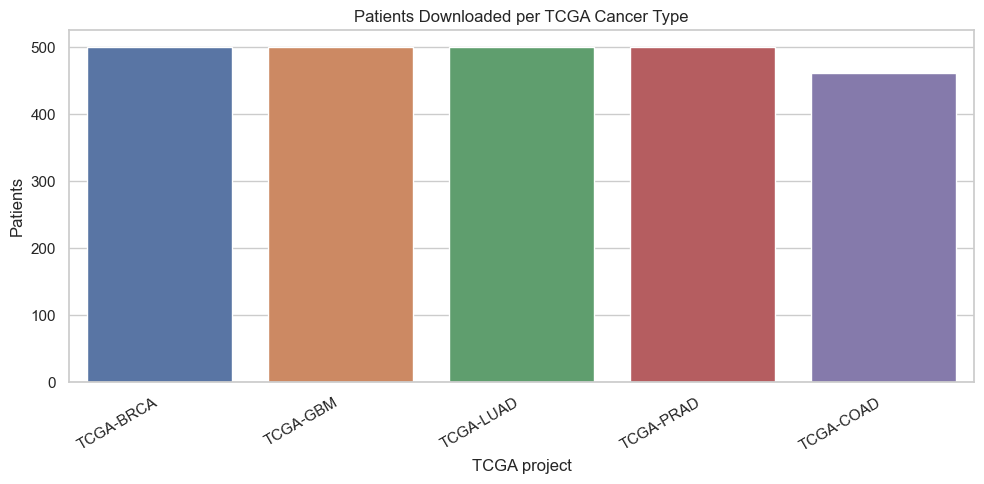

In [10]:
query_1 = """
SELECT
    p.project_id,
    cp.cancer_type_name,
    cp.primary_site,
    COUNT(*) AS patient_count
FROM patients AS p
JOIN cancer_projects AS cp
    ON p.project_id = cp.project_id
GROUP BY
    p.project_id,
    cp.cancer_type_name,
    cp.primary_site
ORDER BY patient_count DESC;
"""

patient_counts = run_sql(query_1)
display(patient_counts)

ax = sns.barplot(data=patient_counts, x="project_id", y="patient_count", hue="project_id", legend=False)
ax.set_title("Patients Downloaded per TCGA Cancer Type")
ax.set_xlabel("TCGA project")
ax.set_ylabel("Patients")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Query 2: Average Age at Diagnosis by Cancer Type and Gender

TCGA stores `age_at_diagnosis` in days. The query divides by `365.25` to convert days into years.

New SQL concepts:

- A **common table expression**, written as `WITH first_diagnosis AS (...)`, creates a temporary named result that only exists for this query.
- `MIN(age_at_diagnosis)` chooses the earliest available diagnosis age for each patient.
- `AVG(...)` computes an average.
- `WHERE` filters out missing or unhelpful values before grouping.
- `ROUND(..., 1)` rounds a number to one decimal place.


,project_id,cancer_type_name,gender,patient_count,avg_age_at_diagnosis_years
0,TCGA-BRCA,Breast Invasive Carcinoma,female,493,59.1
1,TCGA-BRCA,Breast Invasive Carcinoma,male,6,64.1
2,TCGA-COAD,Colon Adenocarcinoma,female,215,66.6
3,TCGA-COAD,Colon Adenocarcinoma,male,242,68.1
4,TCGA-GBM,Glioblastoma Multiforme,female,191,56.7
5,TCGA-GBM,Glioblastoma Multiforme,male,291,57.8
6,TCGA-LUAD,Lung Adenocarcinoma,female,214,65.5
7,TCGA-LUAD,Lung Adenocarcinoma,male,192,65.7
8,TCGA-PRAD,Prostate Adenocarcinoma,male,458,61.5


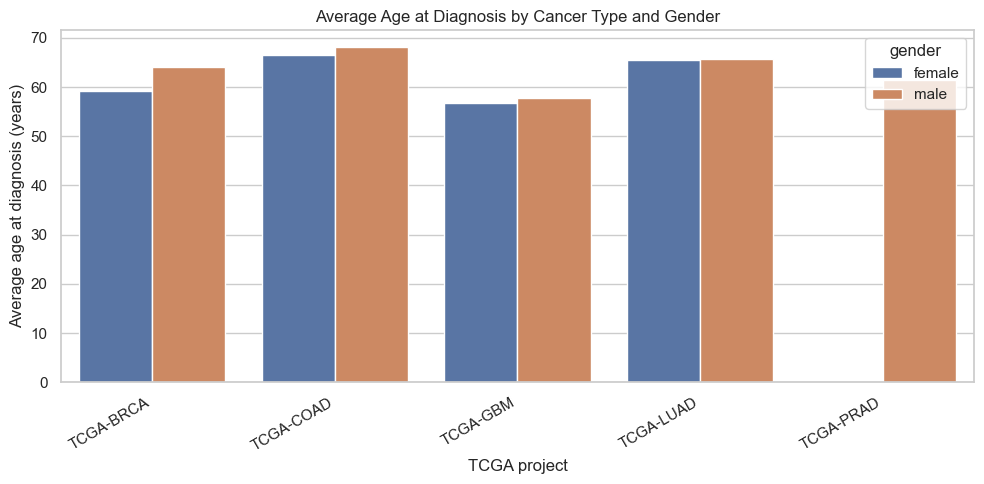

In [11]:
query_2 = """
WITH first_diagnosis AS (
    SELECT
        case_id,
        MIN(age_at_diagnosis) AS age_at_diagnosis
    FROM diagnoses
    WHERE age_at_diagnosis IS NOT NULL
    GROUP BY case_id
)
SELECT
    p.project_id,
    cp.cancer_type_name,
    p.gender,
    COUNT(DISTINCT p.case_id) AS patient_count,
    ROUND(AVG(first_diagnosis.age_at_diagnosis / 365.25), 1) AS avg_age_at_diagnosis_years
FROM patients AS p
JOIN first_diagnosis
    ON p.case_id = first_diagnosis.case_id
JOIN cancer_projects AS cp
    ON p.project_id = cp.project_id
WHERE p.gender IS NOT NULL
  AND LOWER(p.gender) NOT IN ('not reported', 'unknown')
GROUP BY
    p.project_id,
    cp.cancer_type_name,
    p.gender
ORDER BY
    p.project_id,
    p.gender;
"""

age_by_project_gender = run_sql(query_2)
display(age_by_project_gender)

ax = sns.barplot(
    data=age_by_project_gender,
    x="project_id",
    y="avg_age_at_diagnosis_years",
    hue="gender",
)
ax.set_title("Average Age at Diagnosis by Cancer Type and Gender")
ax.set_xlabel("TCGA project")
ax.set_ylabel("Average age at diagnosis (years)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Query 3: Stage Distribution by Cancer Type

Tumor stages often appear as values like `stage i`, `stage iib`, `stage iiic`, or `not reported`.
For plotting, we normalize these detailed labels into broader groups: Stage I, Stage II, Stage III, Stage IV, and Unknown.

New SQL concept:

- `CASE WHEN ... THEN ... ELSE ... END` creates a new value based on conditions.

Notice that the query checks Stage IV before Stage I. That matters because the text `stage iv` also starts with `stage i`.


,project_id,cancer_type_name,stage_group,patient_count
0,TCGA-BRCA,Breast Invasive Carcinoma,Unknown / not reported,500
1,TCGA-COAD,Colon Adenocarcinoma,Unknown / not reported,461
2,TCGA-GBM,Glioblastoma Multiforme,Unknown / not reported,500
3,TCGA-LUAD,Lung Adenocarcinoma,Unknown / not reported,500
4,TCGA-PRAD,Prostate Adenocarcinoma,Unknown / not reported,500


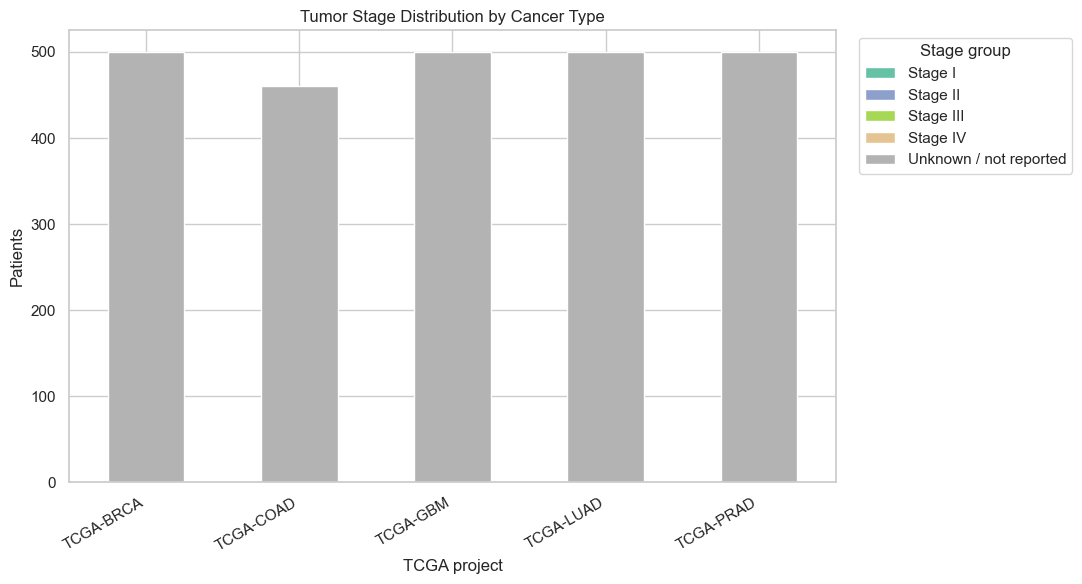

In [12]:
query_3 = """
WITH normalized_stage AS (
    SELECT
        p.case_id,
        p.project_id,
        cp.cancer_type_name,
        CASE
            WHEN d.tumor_stage IS NULL THEN 'Unknown / not reported'
            WHEN LOWER(d.tumor_stage) IN ('not reported', 'unknown', 'not available', 'na') THEN 'Unknown / not reported'
            WHEN LOWER(d.tumor_stage) LIKE '%stage iv%' THEN 'Stage IV'
            WHEN LOWER(d.tumor_stage) LIKE '%stage iii%' THEN 'Stage III'
            WHEN LOWER(d.tumor_stage) LIKE '%stage ii%' THEN 'Stage II'
            WHEN LOWER(d.tumor_stage) LIKE '%stage i%' THEN 'Stage I'
            ELSE d.tumor_stage
        END AS stage_group
    FROM patients AS p
    LEFT JOIN diagnoses AS d
        ON p.case_id = d.case_id
    JOIN cancer_projects AS cp
        ON p.project_id = cp.project_id
)
SELECT
    project_id,
    cancer_type_name,
    stage_group,
    COUNT(DISTINCT case_id) AS patient_count
FROM normalized_stage
GROUP BY
    project_id,
    cancer_type_name,
    stage_group
ORDER BY
    project_id,
    stage_group;
"""

stage_distribution = run_sql(query_3)
display(stage_distribution)

stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV", "Unknown / not reported"]
stage_pivot = (
    stage_distribution
    .pivot_table(index="project_id", columns="stage_group", values="patient_count", fill_value=0)
    .reindex(columns=stage_order, fill_value=0)
)

stage_pivot.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="Set2")
plt.title("Tumor Stage Distribution by Cancer Type")
plt.xlabel("TCGA project")
plt.ylabel("Patients")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Stage group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Query 4: Survival Summary Statistics

Survival data usually has two important pieces:

- **Duration:** how long the patient was observed.
- **Event:** whether the patient died during observation.

For duration, this query uses `days_to_death` when available. If that is missing, it uses `days_to_last_follow_up`.

New SQL concept:

- `COALESCE(a, b)` returns the first non-missing value. Here it means "use death time if present; otherwise use follow-up time."


,project_id,cancer_type_name,patients_with_survival_data,observed_deaths,observed_death_percent,avg_observed_months,avg_time_to_death_months
0,TCGA-GBM,Glioblastoma Multiforme,481,415,86.3,17.5,17.4
1,TCGA-LUAD,Lung Adenocarcinoma,424,156,36.8,30.8,26.1
2,TCGA-COAD,Colon Adenocarcinoma,437,95,21.7,28.6,22.1
3,TCGA-BRCA,Breast Invasive Carcinoma,487,66,13.6,48.5,56.0
4,TCGA-PRAD,Prostate Adenocarcinoma,500,10,2.0,35.9,51.9


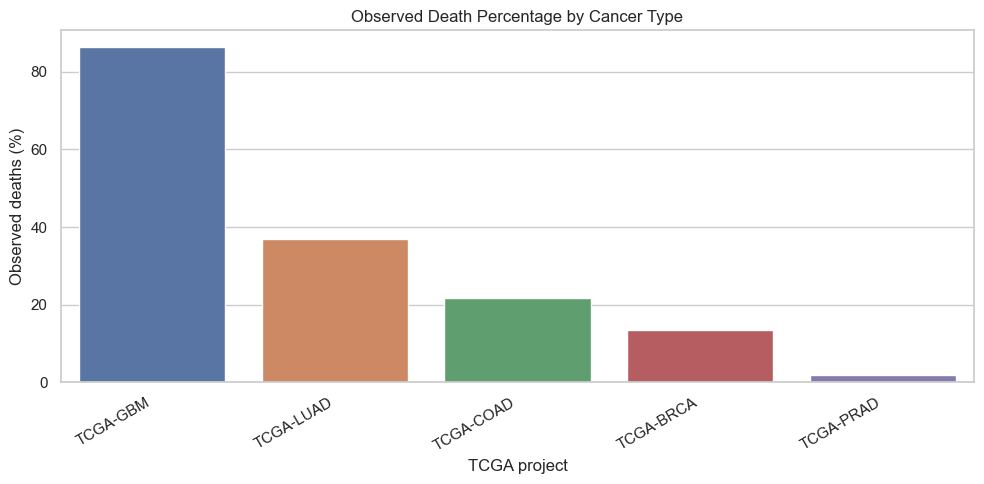

In [13]:
query_4 = """
WITH patient_survival AS (
    SELECT
        p.case_id,
        p.project_id,
        cp.cancer_type_name,
        MAX(COALESCE(d.days_to_death, d.days_to_last_follow_up)) AS observed_days,
        MAX(
            CASE
                WHEN LOWER(COALESCE(p.vital_status, '')) = 'dead' THEN 1
                WHEN d.days_to_death IS NOT NULL THEN 1
                ELSE 0
            END
        ) AS death_event
    FROM patients AS p
    LEFT JOIN diagnoses AS d
        ON p.case_id = d.case_id
    JOIN cancer_projects AS cp
        ON p.project_id = cp.project_id
    GROUP BY
        p.case_id,
        p.project_id,
        cp.cancer_type_name
)
SELECT
    project_id,
    cancer_type_name,
    COUNT(*) AS patients_with_survival_data,
    SUM(death_event) AS observed_deaths,
    ROUND(100.0 * SUM(death_event) / COUNT(*), 1) AS observed_death_percent,
    ROUND(AVG(observed_days) / 30.44, 1) AS avg_observed_months,
    ROUND(AVG(CASE WHEN death_event = 1 THEN observed_days END) / 30.44, 1) AS avg_time_to_death_months
FROM patient_survival
WHERE observed_days IS NOT NULL
  AND observed_days > 0
GROUP BY
    project_id,
    cancer_type_name
ORDER BY observed_death_percent DESC;
"""

survival_summary = run_sql(query_4)
display(survival_summary)

ax = sns.barplot(
    data=survival_summary,
    x="project_id",
    y="observed_death_percent",
    hue="project_id",
    legend=False,
)
ax.set_title("Observed Death Percentage by Cancer Type")
ax.set_xlabel("TCGA project")
ax.set_ylabel("Observed deaths (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Kaplan-Meier Survival Curve

A Kaplan-Meier curve estimates the probability of surviving beyond each time point.

The curve drops when deaths occur. Patients who are still alive at last follow-up are **censored**:
they still contribute information up to their last known follow-up time, but we do not pretend to know what happened after that.

We use SQL to prepare one survival row per patient, then use the `lifelines` Python package to draw the curve.


,case_id,project_id,cancer_type_name,duration_months,event_observed
0,000d566c-96c7-4f1c-b36e-fa2222467983,TCGA-PRAD,Prostate Adenocarcinoma,36.103811,0
1,0045349c-69d9-4306-a403-c9c1fa836644,TCGA-BRCA,Breast Invasive Carcinoma,8.508541,0
2,0075437e-ba1a-46be-86d6-9773209a2b5e,TCGA-LUAD,Lung Adenocarcinoma,40.932983,0
3,0078b0c4-68a9-483b-9aab-61156d263213,TCGA-GBM,Glioblastoma Multiforme,15.932983,1
4,007f9081-5093-4323-b4f8-cd510bf20705,TCGA-PRAD,Prostate Adenocarcinoma,31.471748,0


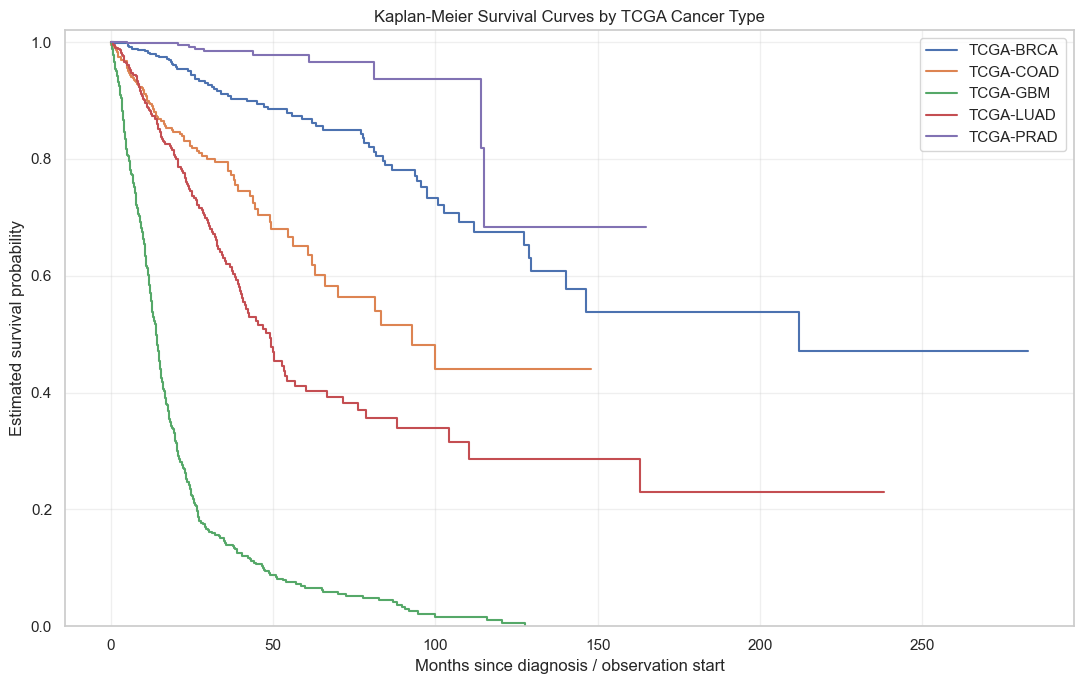

In [14]:
km_sql = """
WITH patient_survival AS (
    SELECT
        p.case_id,
        p.project_id,
        cp.cancer_type_name,
        MAX(COALESCE(d.days_to_death, d.days_to_last_follow_up)) AS duration_days,
        MAX(
            CASE
                WHEN LOWER(COALESCE(p.vital_status, '')) = 'dead' THEN 1
                WHEN d.days_to_death IS NOT NULL THEN 1
                ELSE 0
            END
        ) AS event_observed
    FROM patients AS p
    LEFT JOIN diagnoses AS d
        ON p.case_id = d.case_id
    JOIN cancer_projects AS cp
        ON p.project_id = cp.project_id
    GROUP BY
        p.case_id,
        p.project_id,
        cp.cancer_type_name
)
SELECT
    case_id,
    project_id,
    cancer_type_name,
    duration_days / 30.44 AS duration_months,
    event_observed
FROM patient_survival
WHERE duration_days IS NOT NULL
  AND duration_days > 0;
"""

km_df = run_sql(km_sql)
display(km_df.head())

kmf = KaplanMeierFitter()
plt.figure(figsize=(11, 7))

for project_id, group in km_df.groupby("project_id"):
    if len(group) < 10:
        continue
    kmf.fit(
        durations=group["duration_months"],
        event_observed=group["event_observed"],
        label=project_id,
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival Curves by TCGA Cancer Type")
plt.xlabel("Months since diagnosis / observation start")
plt.ylabel("Estimated survival probability")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Query 5: Mutation Burden by Cancer Type

This query summarizes the mutation-count proxy table.

New SQL idea:

- SQL can analyze tables we created from different API endpoints as long as they share keys.
- Here, `mutation_burden.case_id` links mutation counts back to `patients.case_id`.


,project_id,cancer_type_name,samples_with_maf,avg_mutation_count,min_mutation_count,max_mutation_count
0,TCGA-COAD,Colon Adenocarcinoma,50,41.4,0,72
1,TCGA-GBM,Glioblastoma Multiforme,50,26.7,0,41
2,TCGA-LUAD,Lung Adenocarcinoma,50,24.3,0,48
3,TCGA-BRCA,Breast Invasive Carcinoma,50,15.9,0,25
4,TCGA-PRAD,Prostate Adenocarcinoma,50,5.6,0,14


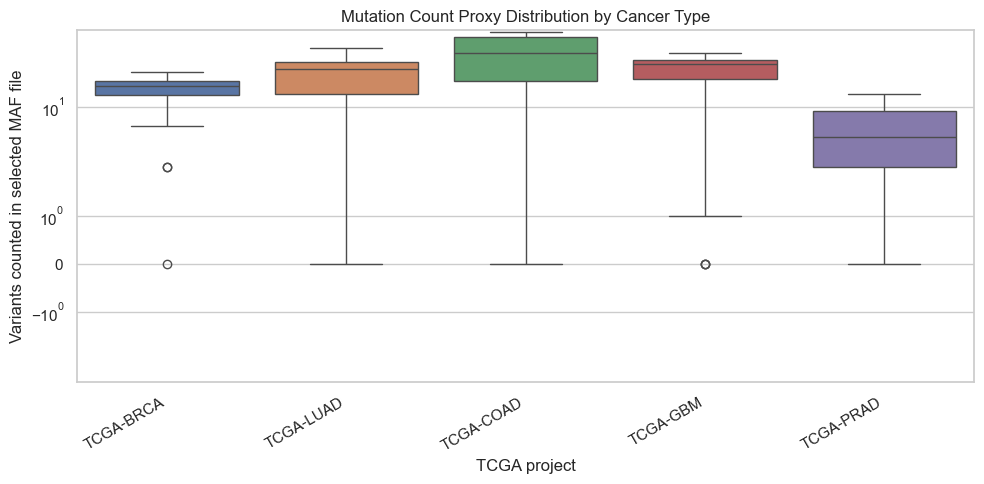

In [15]:
query_5 = """
SELECT
    p.project_id,
    cp.cancer_type_name,
    COUNT(m.case_id) AS samples_with_maf,
    ROUND(AVG(m.mutation_count), 1) AS avg_mutation_count,
    MIN(m.mutation_count) AS min_mutation_count,
    MAX(m.mutation_count) AS max_mutation_count
FROM mutation_burden AS m
JOIN patients AS p
    ON m.case_id = p.case_id
JOIN cancer_projects AS cp
    ON p.project_id = cp.project_id
GROUP BY
    p.project_id,
    cp.cancer_type_name
ORDER BY avg_mutation_count DESC;
"""

mutation_summary = run_sql(query_5)
display(mutation_summary)

mutation_plot_df = run_sql(
    """
    SELECT
        p.project_id,
        m.mutation_count
    FROM mutation_burden AS m
    JOIN patients AS p
        ON m.case_id = p.case_id
    WHERE m.mutation_count IS NOT NULL;
    """
)

ax = sns.boxplot(data=mutation_plot_df, x="project_id", y="mutation_count", hue="project_id", legend=False)
ax.set_title("Mutation Count Proxy Distribution by Cancer Type")
ax.set_xlabel("TCGA project")
ax.set_ylabel("Variants counted in selected MAF file")
ax.set_yscale("symlog")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Query 6: Mutation Burden and Observed Survival

This is an example of a multi-table analysis.

The query joins:

- `patients` for cancer type and vital status,
- `diagnoses` for follow-up/death time,
- `mutation_burden` for mutation counts,
- `cancer_projects` for readable project names.

We split mutation counts into two simple groups:

- `Higher proxy burden`: 200 or more variants in the selected MAF file.
- `Lower proxy burden`: fewer than 200 variants.

The threshold is intentionally simple for teaching. A real scientific analysis would predefine a more careful threshold.


In [16]:
query_6 = """
WITH patient_survival AS (
    SELECT
        p.case_id,
        p.project_id,
        MAX(COALESCE(d.days_to_death, d.days_to_last_follow_up)) AS observed_days,
        MAX(
            CASE
                WHEN LOWER(COALESCE(p.vital_status, '')) = 'dead' THEN 1
                WHEN d.days_to_death IS NOT NULL THEN 1
                ELSE 0
            END
        ) AS death_event
    FROM patients AS p
    LEFT JOIN diagnoses AS d
        ON p.case_id = d.case_id
    GROUP BY
        p.case_id,
        p.project_id
),
burden_groups AS (
    SELECT
        m.case_id,
        m.project_id,
        m.mutation_count,
        CASE
            WHEN m.mutation_count >= 200 THEN 'Higher proxy burden'
            ELSE 'Lower proxy burden'
        END AS mutation_burden_group
    FROM mutation_burden AS m
    WHERE m.mutation_count IS NOT NULL
)
SELECT
    bg.project_id,
    cp.cancer_type_name,
    bg.mutation_burden_group,
    COUNT(*) AS patients,
    ROUND(AVG(bg.mutation_count), 1) AS avg_mutation_count,
    SUM(ps.death_event) AS observed_deaths,
    ROUND(100.0 * SUM(ps.death_event) / COUNT(*), 1) AS observed_death_percent,
    ROUND(AVG(ps.observed_days) / 30.44, 1) AS avg_observed_months
FROM burden_groups AS bg
JOIN patient_survival AS ps
    ON bg.case_id = ps.case_id
JOIN cancer_projects AS cp
    ON bg.project_id = cp.project_id
WHERE ps.observed_days IS NOT NULL
  AND ps.observed_days > 0
GROUP BY
    bg.project_id,
    cp.cancer_type_name,
    bg.mutation_burden_group
ORDER BY
    bg.project_id,
    bg.mutation_burden_group;
"""

mutation_survival = run_sql(query_6)
display(mutation_survival)


,project_id,cancer_type_name,mutation_burden_group,patients,avg_mutation_count,observed_deaths,observed_death_percent,avg_observed_months
0,TCGA-BRCA,Breast Invasive Carcinoma,Lower proxy burden,50,15.9,3,6.0,55.0
1,TCGA-COAD,Colon Adenocarcinoma,Lower proxy burden,48,42.4,6,12.5,27.0
2,TCGA-GBM,Glioblastoma Multiforme,Lower proxy burden,50,26.7,40,80.0,17.9
3,TCGA-LUAD,Lung Adenocarcinoma,Lower proxy burden,40,25.4,15,37.5,37.4
4,TCGA-PRAD,Prostate Adenocarcinoma,Lower proxy burden,50,5.6,0,0.0,25.4


## Query 7: Treatment Patterns

This query counts treatment records by cancer type and treatment type.

New SQL concept:

- `LEFT JOIN` keeps all patients even if they do not have a matching treatment row.

We use a `WHERE` filter to remove missing treatment labels after the join, because the goal is to summarize known treatments.


In [17]:
query_7 = """
SELECT
    p.project_id,
    cp.cancer_type_name,
    COALESCE(t.treatment_type, 'Unknown / not reported') AS treatment_type,
    COALESCE(t.treatment_or_therapy, 'Unknown / not reported') AS treatment_or_therapy,
    COUNT(DISTINCT p.case_id) AS patient_count
FROM patients AS p
LEFT JOIN treatments AS t
    ON p.case_id = t.case_id
JOIN cancer_projects AS cp
    ON p.project_id = cp.project_id
WHERE t.treatment_type IS NOT NULL
   OR t.treatment_or_therapy IS NOT NULL
GROUP BY
    p.project_id,
    cp.cancer_type_name,
    treatment_type,
    treatment_or_therapy
ORDER BY
    p.project_id,
    patient_count DESC;
"""

treatment_patterns = run_sql(query_7)
display(treatment_patterns.head(30))


,project_id,cancer_type_name,treatment_type,treatment_or_therapy,patient_count


## Query 8: Exposure Trends

Exposure records can include smoking, alcohol history, pack-years smoked, and BMI.

TCGA smoking status is often stored as a code. The `CASE` expression below gives common codes readable labels when possible.
If a project uses text instead of a code, the query keeps the original value.


,project_id,cancer_type_name,smoking_status,patient_count,avg_pack_years_smoked,avg_bmi
0,TCGA-BRCA,Breast Invasive Carcinoma,Unknown / not reported,500,NaN,None
1,TCGA-COAD,Colon Adenocarcinoma,Unknown / not reported,461,NaN,None
2,TCGA-GBM,Glioblastoma Multiforme,Unknown / not reported,500,NaN,None
3,TCGA-LUAD,Lung Adenocarcinoma,Current Reformed Smoker for < or = 15 yrs,147,43.4,None
4,TCGA-LUAD,Lung Adenocarcinoma,Current Smoker,108,48.2,None
5,TCGA-LUAD,Lung Adenocarcinoma,Current Reformed Smoker for > 15 yrs,99,28.9,None
6,TCGA-LUAD,Lung Adenocarcinoma,Lifelong Non-Smoker,67,NaN,None
7,TCGA-LUAD,Lung Adenocarcinoma,Unknown / not reported,63,NaN,None
8,TCGA-LUAD,Lung Adenocarcinoma,Not Reported,12,NaN,None
9,TCGA-LUAD,Lung Adenocarcinoma,"Current Reformed Smoker, Duration Not Specified",2,30.0,None


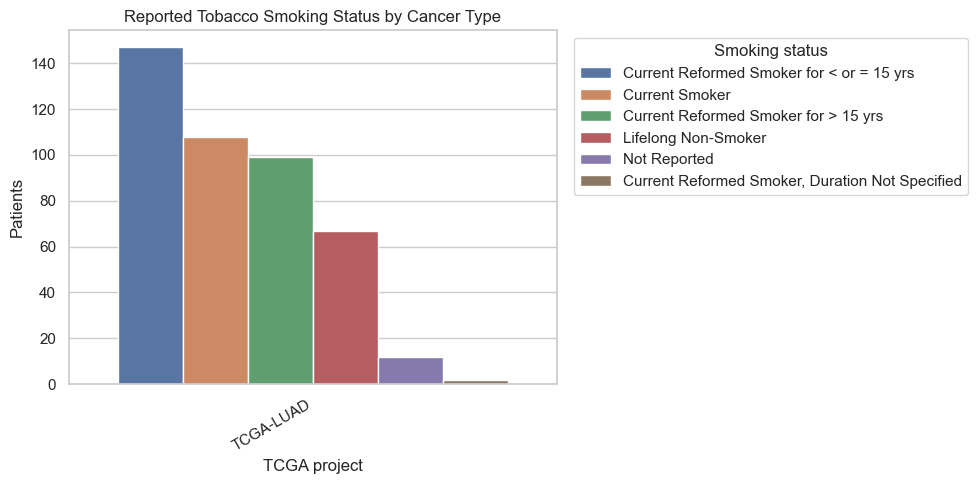

In [18]:
query_8 = """
SELECT
    p.project_id,
    cp.cancer_type_name,
    CASE
        WHEN e.tobacco_smoking_status IS NULL THEN 'Unknown / not reported'
        WHEN CAST(e.tobacco_smoking_status AS TEXT) = '1' THEN 'Lifelong non-smoker'
        WHEN CAST(e.tobacco_smoking_status AS TEXT) = '2' THEN 'Current smoker'
        WHEN CAST(e.tobacco_smoking_status AS TEXT) = '3' THEN 'Current reformed smoker >15 years'
        WHEN CAST(e.tobacco_smoking_status AS TEXT) = '4' THEN 'Current reformed smoker <=15 years'
        WHEN CAST(e.tobacco_smoking_status AS TEXT) = '5' THEN 'Current reformed smoker, years unknown'
        ELSE CAST(e.tobacco_smoking_status AS TEXT)
    END AS smoking_status,
    COUNT(DISTINCT p.case_id) AS patient_count,
    ROUND(AVG(e.pack_years_smoked), 1) AS avg_pack_years_smoked,
    ROUND(AVG(e.bmi), 1) AS avg_bmi
FROM patients AS p
LEFT JOIN exposures AS e
    ON p.case_id = e.case_id
JOIN cancer_projects AS cp
    ON p.project_id = cp.project_id
GROUP BY
    p.project_id,
    cp.cancer_type_name,
    smoking_status
ORDER BY
    p.project_id,
    patient_count DESC;
"""

exposure_trends = run_sql(query_8)
display(exposure_trends.head(40))

smoking_plot = exposure_trends[exposure_trends["smoking_status"] != "Unknown / not reported"].copy()
top_smoking_statuses = (
    smoking_plot.groupby("smoking_status")["patient_count"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)
smoking_plot = smoking_plot[smoking_plot["smoking_status"].isin(top_smoking_statuses)]

if not smoking_plot.empty:
    ax = sns.barplot(
        data=smoking_plot,
        x="project_id",
        y="patient_count",
        hue="smoking_status",
    )
    ax.set_title("Reported Tobacco Smoking Status by Cancer Type")
    ax.set_xlabel("TCGA project")
    ax.set_ylabel("Patients")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Smoking status", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No non-missing smoking-status values were available for plotting.")


## Query 9: Primary Diagnosis Patterns

This query finds the most common primary diagnosis labels in each project.

New SQL concept:

- `ROW_NUMBER() OVER (...)` is a **window function**. It ranks rows inside each project.
- The outer query keeps only the top five diagnosis labels per project.


In [19]:
query_9 = """
WITH diagnosis_counts AS (
    SELECT
        p.project_id,
        cp.cancer_type_name,
        COALESCE(d.primary_diagnosis, 'Unknown / not reported') AS primary_diagnosis,
        COUNT(DISTINCT p.case_id) AS patient_count
    FROM patients AS p
    LEFT JOIN diagnoses AS d
        ON p.case_id = d.case_id
    JOIN cancer_projects AS cp
        ON p.project_id = cp.project_id
    GROUP BY
        p.project_id,
        cp.cancer_type_name,
        primary_diagnosis
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY project_id
            ORDER BY patient_count DESC
        ) AS diagnosis_rank
    FROM diagnosis_counts
)
SELECT
    project_id,
    cancer_type_name,
    diagnosis_rank,
    primary_diagnosis,
    patient_count
FROM ranked
WHERE diagnosis_rank <= 5
ORDER BY
    project_id,
    diagnosis_rank;
"""

diagnosis_patterns = run_sql(query_9)
display(diagnosis_patterns)


,project_id,cancer_type_name,diagnosis_rank,primary_diagnosis,patient_count
0,TCGA-BRCA,Breast Invasive Carcinoma,1,"Infiltrating duct carcinoma, NOS",350
1,TCGA-BRCA,Breast Invasive Carcinoma,2,"Lobular carcinoma, NOS",100
2,TCGA-BRCA,Breast Invasive Carcinoma,3,Not Reported,54
3,TCGA-BRCA,Breast Invasive Carcinoma,4,Infiltrating duct and lobular carcinoma,11
4,TCGA-BRCA,Breast Invasive Carcinoma,5,Infiltrating duct mixed with other types of ca...,11
5,TCGA-COAD,Colon Adenocarcinoma,1,"Adenocarcinoma, NOS",390
6,TCGA-COAD,Colon Adenocarcinoma,2,Not Reported,114
7,TCGA-COAD,Colon Adenocarcinoma,3,Mucinous adenocarcinoma,63
8,TCGA-COAD,Colon Adenocarcinoma,4,"Carcinoma in situ, NOS",3
9,TCGA-COAD,Colon Adenocarcinoma,5,"Basal cell carcinoma, NOS",2


## 7. What This Warehouse Teaches

You built a real SQL-backed clinical data warehouse from public TCGA data.

The most important SQL ideas were:

- Tables store different kinds of entities: patients, diagnoses, treatments, exposures, projects, and mutation summaries.
- Primary keys identify rows.
- Foreign keys connect tables.
- `JOIN` combines related tables.
- `GROUP BY` creates summaries.
- Aggregates such as `COUNT`, `AVG`, `MIN`, and `MAX` turn many rows into statistics.
- `CASE` creates readable categories from messy real-world labels.
- `COALESCE` handles missing values.
- Common table expressions make long queries easier to read.

The same pattern is used in real clinical analytics: download or receive source data, normalize it into reliable tables,
query the tables with SQL, and visualize the query results with Python.


In [20]:
conn.close()
print("Database connection closed. Notebook completed successfully.")


Database connection closed. Notebook completed successfully.
